# Prediksi Pit Stop Formula 1 Menggunakan Algoritma Random Forest


**Nama Mahasiswa :** Lala Hanisa<br>
**NIM :** 1224160104<br>
**Program Studi :** Sistem Informasi<br>
**Kelas :** SI 24 P SIM 2<br>
**Mata Kuliah :** Konsep Data Warehouse dan Data Mining<br>
**Dosen Pengampu :** Agus Rifaldi S.Kom


# Metode Klasifikasi: Random Forest

# Fase 1 - Business Understanding

## Latar Belakang Masalah

Dalam dunia Formula 1, strategi pit stop merupakan salah satu faktor penting yang dapat menentukan hasil akhir balapan. Keputusan untuk melakukan pit stop dipengaruhi oleh berbagai faktor seperti kondisi ban, umur ban, posisi pembalap, performa lap, dan progres balapan.

Keputusan yang terlambat atau terlalu cepat dapat menyebabkan kehilangan waktu yang berdampak pada posisi pembalap. Oleh karena itu, diperlukan analisis data untuk membantu memprediksi kapan pit stop sebaiknya dilakukan berdasarkan kondisi balapan yang tersedia.

Melalui teknik Data Mining, model klasifikasi dapat digunakan untuk mempelajari pola dari data historis balapan Formula 1 dan memprediksi kemungkinan pit stop pada kondisi tertentu.

## Tujuan Project

Tujuan dari project ini adalah:

1. Membangun model klasifikasi untuk memprediksi keputusan pit stop Formula 1 menggunakan algoritma Random Forest.
2. Mengidentifikasi faktor-faktor yang paling berpengaruh terhadap keputusan pit stop.
3. Mengukur performa model menggunakan metrik evaluasi klasifikasi seperti Accuracy, Precision, Recall, dan F1-Score.
4. Menerapkan metode CRISP-DM dalam proses pengolahan dan analisis data.

## Pertanyaan Analitik

1. Faktor apa saja yang paling mempengaruhi keputusan pit stop pembalap Formula 1?
2. Seberapa baik model Random Forest dalam memprediksi pit stop berdasarkan data historis?
3. Berapa tingkat Accuracy, Precision, Recall, dan F1-Score yang dihasilkan oleh model?

## Manfaat Analisis

### Bagi Tim Formula 1

Membantu memahami faktor-faktor yang mempengaruhi keputusan pit stop dan mendukung pengambilan keputusan strategi balapan.

### Bagi Dunia Data Mining

Menunjukkan penerapan teknik klasifikasi menggunakan algoritma Random Forest pada data olahraga dan strategi balapan.

### Bagi Mahasiswa

Menambah pemahaman mengenai proses Data Mining menggunakan framework CRISP-DM mulai dari Business Understanding hingga Deployment.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
np.random.seed(42)
print('Library berhasil diimport!')

Library berhasil diimport!


In [2]:
# ======================================================
# FASE 2 - DATA UNDERSTANDING
# ======================================================

# Menampilkan garis pembatas agar output terlihat lebih rapi dan mudah dibaca
print('=' * 60)

# Menampilkan judul tahap Data Understanding untuk analisis prediksi pit stop Formula 1
print('  FASE 2: DATA UNDERSTANDING - Prediksi Pit Stop F1')

# Menampilkan garis pembatas bawah
print('=' * 60)

# Membaca dataset F1 dari file CSV menggunakan library pandas
df1 = pd.read_csv('f1_strategy_dataset_v4.csv')
# Menampilkan dataset
print('\nPREVIEW DATASET')
print('-' * 60)

display(df1)

# ======================================================
# DESKRIPSI DATASET
# ======================================================

print('\nDESKRIPSI DATASET:')

print('''
Dataset yang digunakan adalah F1 Strategy Dataset Pit Stop Prediction
yang diperoleh dari Kaggle. Dataset ini berisi data historis strategi
balapan Formula 1 yang digunakan untuk memprediksi kemungkinan
pembalap melakukan pit stop pada lap berikutnya.

Dataset terdiri dari berbagai atribut yang menggambarkan kondisi
balapan, kondisi ban, posisi pembalap, performa lap, serta progres
balapan yang digunakan sebagai fitur dalam proses klasifikasi.
''')

# ======================================================
# INFORMASI UKURAN DATASET
# ======================================================

# Menampilkan jumlah baris dan jumlah kolom yang terdapat pada dataset
print(f'Shape Dataset : {df1.shape[0]} baris dan {df1.shape[1]} kolom')

# Menampilkan seluruh nama kolom atau atribut yang tersedia dalam dataset
print(f'\nKolom Dataset:')
print(list(df1.columns))

# ======================================================
# DESKRIPSI ATRIBUT
# ======================================================

attribute_desc = pd.DataFrame({
    'No': range(1, 17),

    'Attribute Name': [
        'Driver',
        'LapNumber',
        'Compound',
        'Stint',
        'TyreLife',
        'Position',
        'LapTime (s)',
        'Race',
        'Year',
        'LapTime_Delta',
        'Cumulative_Degradation',
        'PitStop',
        'PitNextLap',
        'RaceProgress',
        'Normalized_TyreLife',
        'Position_Change'
    ],

    'Data Type': [
        'Object',
        'Integer',
        'Object',
        'Integer',
        'Float',
        'Integer',
        'Float',
        'Object',
        'Integer',
        'Float',
        'Float',
        'Integer',
        'Integer',
        'Float',
        'Float',
        'Float'
    ],

    'Description': [
        'Nama pembalap Formula 1',
        'Nomor lap saat data dicatat',
        'Jenis ban yang digunakan pembalap',
        'Urutan penggunaan ban dalam balapan',
        'Umur ban dalam jumlah lap',
        'Posisi pembalap dalam balapan',
        'Waktu lap dalam satuan detik',
        'Nama Grand Prix atau balapan',
        'Tahun penyelenggaraan balapan',
        'Selisih waktu lap terhadap referensi',
        'Akumulasi degradasi ban',
        'Status pit stop pada lap saat ini',
        'Target klasifikasi pit stop lap berikutnya',
        'Persentase progres balapan',
        'Nilai TyreLife yang telah dinormalisasi',
        'Perubahan posisi pembalap'
    ]
})

print('\nDESKRIPSI ATRIBUT DATASET:')
display(attribute_desc)

# ======================================================
# TIPE DATA
# ======================================================

print('\nTipe Data Setiap Kolom:')
print(df1.info())

# ======================================================
# STATISTIK DESKRIPTIF
# ======================================================

print('\nStatistik Deskriptif:')

display(
    df1.describe())

# ======================================================
# RINGKASAN TIPE DATA
# ======================================================

print('\nRingkasan Tipe Data:')

print(f'Kolom Object  : {len(df1.select_dtypes(include="object").columns)}')
print(f'Kolom Integer : {len(df1.select_dtypes(include="int64").columns)}')
print(f'Kolom Float   : {len(df1.select_dtypes(include="float64").columns)}')

print('\nTarget Klasifikasi:')
print('PitNextLap')
print('0 = Tidak Pit Stop')
print('1 = Pit Stop pada Lap Berikutnya')

  FASE 2: DATA UNDERSTANDING - Prediksi Pit Stop F1

PREVIEW DATASET
------------------------------------------------------------


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101366,ZHO,52,HARD,3,29.0,12,103.373,United States Grand Prix,2022,26.850,-90.264,0,0,0.722222,0.852941,2.0
101367,ZHO,53,HARD,3,30.0,13,105.200,United States Grand Prix,2022,27.061,-88.437,0,0,0.736111,0.882353,1.0
101368,ZHO,54,HARD,3,31.0,13,104.102,United States Grand Prix,2022,27.149,-89.535,0,0,0.750000,0.911765,0.0
101369,ZHO,55,HARD,3,32.0,14,103.812,United States Grand Prix,2022,4.428,-89.825,0,0,0.763889,0.941176,-1.0



DESKRIPSI DATASET:

Dataset yang digunakan adalah F1 Strategy Dataset Pit Stop Prediction
yang diperoleh dari Kaggle. Dataset ini berisi data historis strategi
balapan Formula 1 yang digunakan untuk memprediksi kemungkinan
pembalap melakukan pit stop pada lap berikutnya.

Dataset terdiri dari berbagai atribut yang menggambarkan kondisi
balapan, kondisi ban, posisi pembalap, performa lap, serta progres
balapan yang digunakan sebagai fitur dalam proses klasifikasi.

Shape Dataset : 101371 baris dan 16 kolom

Kolom Dataset:
['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']

DESKRIPSI ATRIBUT DATASET:


,No,Attribute Name,Data Type,Description
0,1,Driver,Object,Nama pembalap Formula 1
1,2,LapNumber,Integer,Nomor lap saat data dicatat
2,3,Compound,Object,Jenis ban yang digunakan pembalap
3,4,Stint,Integer,Urutan penggunaan ban dalam balapan
4,5,TyreLife,Float,Umur ban dalam jumlah lap
5,6,Position,Integer,Posisi pembalap dalam balapan
6,7,LapTime (s),Float,Waktu lap dalam satuan detik
7,8,Race,Object,Nama Grand Prix atau balapan
8,9,Year,Integer,Tahun penyelenggaraan balapan
9,10,LapTime_Delta,Float,Selisih waktu lap terhadap referensi



Tipe Data Setiap Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64


,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000



Ringkasan Tipe Data:
Kolom Object  : 3
Kolom Integer : 6
Kolom Float   : 7

Target Klasifikasi:
PitNextLap
0 = Tidak Pit Stop
1 = Pit Stop pada Lap Berikutnya


In [3]:
# ======================================================
# IDENTIFIKASI MASALAH DATA
# ======================================================

# Menampilkan judul identifikasi data
print('IDENTIFIKASI DATA KOTOR:')

# ======================================================
# 1. Missing Values
# ======================================================

# Menampilkan jumlah missing value pada setiap kolom
print('\n1. Missing Values:')
print(df1.isnull().sum())

# ======================================================
# 2. Data Duplikat
# ======================================================

# Menampilkan jumlah baris yang terdeteksi duplikat
print(f'\n2. Duplikat: {df1.duplicated().sum()} baris')

# ======================================================
# 3. Nilai Unik Compound
# ======================================================

# Menampilkan nilai unik pada kolom Compound
# untuk mengecek kemungkinan typo atau inkonsistensi penulisan
print('\n3. Nilai unik Compound (cek typo):')
print(df1['Compound'].value_counts(dropna=False))

# ======================================================
# 4. Nilai Tidak Masuk Akal
# ======================================================

print('\n4. Nilai tidak masuk akal:')

# Mengecek TyreLife negatif
print(f'   TyreLife < 0               : {(df1["TyreLife"] < 0).sum()} baris')

# Mengecek Position kurang dari 1
print(f'   Position < 1              : {(df1["Position"] < 1).sum()} baris')

# Mengecek LapNumber kurang dari 1
print(f'   LapNumber < 1             : {(df1["LapNumber"] < 1).sum()} baris')

# Mengecek LapTime kurang dari atau sama dengan 0
print(f'   LapTime (s) <= 0          : {(df1["LapTime (s)"] <= 0).sum()} baris')

IDENTIFIKASI DATA KOTOR:

1. Missing Values:
Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

2. Duplikat: 0 baris

3. Nilai unik Compound (cek typo):
Compound
HARD            44967
MEDIUM          37639
SOFT            12744
INTERMEDIATE     5556
WET               399
NaN                66
Name: count, dtype: int64

4. Nilai tidak masuk akal:
   TyreLife < 0               : 0 baris
   Position < 1              : 0 baris
   LapNumber < 1             : 0 baris
   LapTime (s) <= 0          : 0 baris


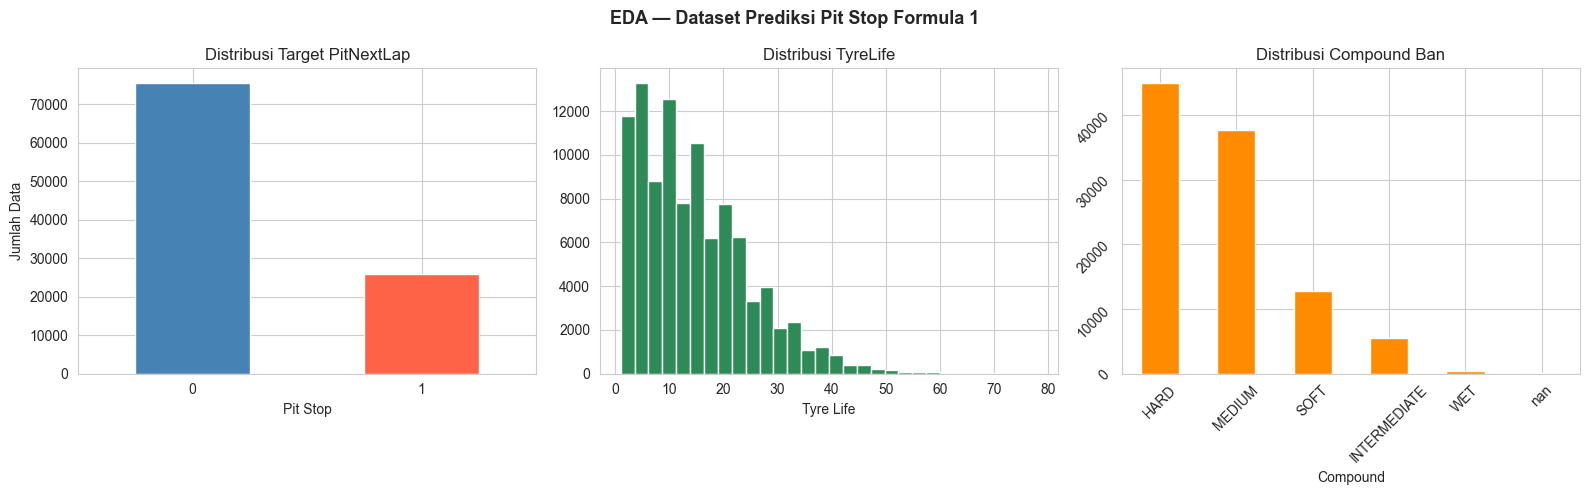

In [4]:
# ======================================================
# EXPLORATORY DATA ANALYSIS (EDA) - DATA F1
# ======================================================

# Membuat figure dengan 3 subplot berjajar horizontal dengan ukuran 16x5 inch
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Menambahkan judul utama untuk keseluruhan visualisasi EDA dataset F1
fig.suptitle(
    'EDA — Dataset Prediksi Pit Stop Formula 1',
    fontsize=13,
    fontweight='bold'
)

# ======================================================
# SUBPLOT 1 : DISTRIBUSI TARGET PITNEXTLAP
# ======================================================

# Menghitung jumlah data pada masing-masing kelas target PitNextLap
# 0 = Tidak Pit Stop
# 1 = Pit Stop pada lap berikutnya
df1['PitNextLap'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='white'
)

# Menambahkan judul pada subplot pertama
axes[0].set_title('Distribusi Target PitNextLap')

# Menambahkan label sumbu X
axes[0].set_xlabel('Pit Stop')

# Menambahkan label sumbu Y
axes[0].set_ylabel('Jumlah Data')

# Mengatur label sumbu X agar tidak berputar
axes[0].tick_params(rotation=0)

# ======================================================
# SUBPLOT 2 : DISTRIBUSI TYRELIFE
# ======================================================

# Membuat histogram untuk melihat distribusi umur ban (TyreLife)
# dropna() digunakan untuk menghapus missing value sementara
df1['TyreLife'].dropna().hist(
    ax=axes[1],
    bins=30,
    color='seagreen',
    edgecolor='white'
)

# Menambahkan judul pada subplot kedua
axes[1].set_title('Distribusi TyreLife')

# Menambahkan label sumbu X
axes[1].set_xlabel('Tyre Life')

# ======================================================
# SUBPLOT 3 : DISTRIBUSI COMPOUND BAN
# ======================================================

# Menghitung jumlah setiap jenis compound ban
# dropna=False digunakan agar nilai kosong tetap dihitung
df1['Compound'].value_counts(dropna=False).plot(
    kind='bar',
    ax=axes[2],
    color='darkorange',
    edgecolor='white'
)

# Menambahkan judul pada subplot ketiga
axes[2].set_title('Distribusi Compound Ban')

# Memutar label sumbu X agar tidak saling bertumpuk
axes[2].tick_params(rotation=45)

# Merapikan tata letak antar subplot
plt.tight_layout()

# Menampilkan seluruh visualisasi EDA
plt.show()

# Phase 3 Data Prepation

In [5]:
# ============================================================
# FASE 3 - DATA PREPARATION
# ============================================================

# Menampilkan garis pembatas atas
print('-' * 60)

# Menampilkan judul tahap Data Preparation
print('FASE 3: DATA PREPARATION')

# Menampilkan garis pembatas bawah
print('-' * 60)

# Membuat salinan dataset asli agar data original tetap aman
df1_clean = df1.copy()

# ============================================================
# STEP 1 - MENGHAPUS DATA DUPLIKAT
# ============================================================

# Menyimpan jumlah data sebelum proses penghapusan duplikat
before = len(df1_clean)

# Menghapus baris data yang duplikat
df1_clean = df1_clean.drop_duplicates()

# Menampilkan jumlah data yang berhasil dihapus
print(f'\nStep 1 | Hapus Duplikat : {(before - len(df1_clean))} baris dihapus')

------------------------------------------------------------
FASE 3: DATA PREPARATION
------------------------------------------------------------

Step 1 | Hapus Duplikat : 0 baris dihapus


In [6]:
# ============================================================
# FASE 3 - DATA PREPARATION
# ============================================================

# Menampilkan garis pembatas atas agar output lebih rapi
print('-' * 60)

# Menampilkan judul tahap Data Preparation
print('FASE 3: DATA PREPARATION')

# Menampilkan garis pembatas bawah
print('-' * 60)

# Membuat salinan dataset asli agar data original tetap aman
# dan tidak berubah selama proses cleaning
df1_clean = df1.copy()

# ============================================================
# STEP 1 - MENGHAPUS DATA DUPLIKAT
# ============================================================

# Menyimpan jumlah data sebelum proses penghapusan duplikat
before = len(df1_clean)

# Menghapus seluruh baris yang memiliki data identik
# pada semua kolom dataset
df1_clean = df1_clean.drop_duplicates()

# Menampilkan jumlah data duplikat yang berhasil dihapus
print(
    f'\nStep 1 | Hapus Duplikat : '
    f'{(before - len(df1_clean))} baris dihapus'
)

------------------------------------------------------------
FASE 3: DATA PREPARATION
------------------------------------------------------------

Step 1 | Hapus Duplikat : 0 baris dihapus


In [7]:
# ============================================================
# STEP 3 - STANDARDISASI NILAI COMPOUND BAN
# ============================================================

# Membuat dictionary untuk menyeragamkan penulisan jenis compound ban
# agar tidak terjadi perbedaan huruf besar dan huruf kecil
compound_map = {
    'soft': 'SOFT',
    'Soft': 'SOFT',
    'medium': 'MEDIUM',
    'Medium': 'MEDIUM',
    'hard': 'HARD',
    'Hard': 'HARD'
}

# Menghitung jumlah nilai unik pada kolom Compound sebelum standardisasi
before_unique = df1_clean['Compound'].nunique()

# Mengganti nilai pada kolom Compound berdasarkan dictionary mapping
# sehingga seluruh penulisan compound menjadi konsisten
df1_clean['Compound'] = df1_clean['Compound'].replace(compound_map)

# Menghitung jumlah nilai unik setelah proses standardisasi
after_unique = df1_clean['Compound'].nunique()

# Menampilkan perubahan jumlah nilai unik sebelum dan sesudah cleaning
print(
    f'Step 3 | Standardisasi Compound: '
    f'{before_unique} -> {after_unique} nilai unik'
)

Step 3 | Standardisasi Compound: 5 -> 5 nilai unik


In [8]:
# ============================================================
# STEP 4 - MENGHAPUS NILAI TIDAK MASUK AKAL (OUTLIER)
# ============================================================

# Menyimpan jumlah data sebelum proses filtering
before = len(df1_clean)

# Memfilter dataset agar hanya menyisakan data yang memiliki nilai valid
# pada atribut numerik yang digunakan dalam analisis
df1_clean = df1_clean[
    
    # TyreLife tidak boleh bernilai negatif karena umur ban tidak mungkin kurang dari nol
    (df1_clean['TyreLife'] >= 0) &
    
    # Position minimal bernilai 1 karena posisi balapan dimulai dari peringkat pertama
    (df1_clean['Position'] >= 1) &
    
    # LapNumber minimal bernilai 1 karena nomor lap tidak mungkin bernilai nol atau negatif
    (df1_clean['LapNumber'] >= 1) &
    
    # LapTime harus lebih besar dari 0 detik karena waktu lap tidak mungkin nol atau negatif
    (df1_clean['LapTime (s)'] > 0)
]

# Menampilkan jumlah data yang dihapus karena memiliki nilai tidak valid
print(
    f'Step 4 | Hapus Outlier Data F1 : '
    f'{before - len(df1_clean)} baris'
)

Step 4 | Hapus Outlier Data F1 : 0 baris


In [9]:
# ============================================================
# STEP 5 - MEMASTIKAN NILAI POSITION MASIH VALID
# ============================================================

# Menyimpan jumlah data sebelum proses filtering
before = len(df1_clean)

# Memfilter data agar hanya menyisakan posisi balapan yang valid
# Dalam Formula 1 posisi pembalap umumnya berada pada rentang 1 sampai 20
df1_clean = df1_clean[
    
    # Nilai kosong (NaN) tetap dipertahankan sementara
    (df1_clean['Position'].isna()) |
    
    # Position harus berada dalam rentang yang valid
    (
        (df1_clean['Position'] >= 1) &
        (df1_clean['Position'] <= 20)
    )
]

# Menampilkan jumlah data yang dihapus karena memiliki posisi tidak valid
print(
    f'Step 5 | Hapus Outlier Position : '
    f'{before - len(df1_clean)} baris'
)

Step 5 | Hapus Outlier Position : 0 baris


In [10]:
# ============================================================
# STEP 6 - MEMASTIKAN NILAI STINT VALID
# ============================================================

# Menyimpan jumlah data sebelum proses filtering
before = len(df1_clean)

# Memfilter data agar hanya menyisakan nilai Stint yang valid
# Stint menunjukkan urutan penggunaan ban selama balapan
df1_clean = df1_clean[
    
    # Nilai kosong (NaN) tetap dipertahankan sementara
    (df1_clean['Stint'].isna()) |
    
    # Nilai Stint harus minimal 1
    (df1_clean['Stint'] >= 1)
]

# Menampilkan jumlah data yang dihapus karena memiliki nilai Stint tidak valid
print(
    f'Step 6 | Hapus Stint Tidak Valid : '
    f'{before - len(df1_clean)} baris'
)

Step 6 | Hapus Stint Tidak Valid : 0 baris


In [11]:
# ============================================================
# STEP 7 - IMPUTASI MISSING VALUES
# ============================================================

# Mengisi missing value pada kolom numerik menggunakan median
# Median dipilih karena lebih stabil dan tidak mudah terpengaruh oleh outlier

for col in [
    'TyreLife',
    'Position',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation'
]:
    
    # Menghitung nilai median dari kolom yang sedang diproses
    median_val = df1_clean[col].median()
    
    # Mengganti nilai yang kosong (NaN) dengan nilai median
    df1_clean[col] = df1_clean[col].fillna(median_val)

# Mengisi missing value pada kolom kategorikal menggunakan modus
# Modus dipilih karena merupakan nilai yang paling sering muncul

for col in [
    'Compound',
    'Driver',
    'Race'
]:
    
    # Mengambil nilai modus dari kolom
    mode_val = df1_clean[col].mode()[0]
    
    # Mengganti nilai yang kosong (NaN) dengan nilai modus
    df1_clean[col] = df1_clean[col].fillna(mode_val)

# Menampilkan informasi bahwa proses imputasi berhasil dilakukan
print('Step 7 | Imputasi Missing : selesai')

# Menampilkan ukuran dataset setelah proses cleaning
print(f'\nShape AKHIR: {df1_clean.shape}')

# Menampilkan jumlah missing value yang masih tersisa
print(f'Missing sisa : {df1_clean.isnull().sum().sum()}')

Step 7 | Imputasi Missing : selesai

Shape AKHIR: (101371, 16)
Missing sisa : 0


In [12]:
# ============================================================
# ENCODING DATA KATEGORIKAL UNTUK RANDOM FOREST
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Membuat salinan dataset hasil cleaning
df1_model = df1_clean.copy()

# Dictionary untuk menyimpan encoder
le_dict = {}

# Kolom kategorikal yang perlu diubah menjadi numerik
cat_cols = [
    'Driver',
    'Compound',
    'Race'
]

for col in cat_cols:

    le = LabelEncoder()

    df1_model[col] = le.fit_transform(
        df1_model[col].astype(str)
    )

    le_dict[col] = le

print('Step 8 | Encoding Data : selesai')

print('\nData setelah encoding:')
df1_model.head()

Step 8 | Encoding Data : selesai

Data setelah encoding:


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,0,1,2,1,2.0,17,100.625,0,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,0,2,2,1,3.0,18,93.560,0,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,0,3,2,1,4.0,18,91.768,0,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,0,4,2,1,5.0,18,91.591,0,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,0,5,2,1,6.0,18,91.422,0,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


# Phase 4 Modelling

In [13]:
# ============================================================
# FASE 4 - MODELING: Random Forest
# ============================================================

# Mengimport algoritma Random Forest
from sklearn.ensemble import RandomForestClassifier

# Mengimport train_test_split untuk membagi data training dan testing
# cross_val_score digunakan untuk evaluasi tambahan menggunakan cross validation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

# Mengimport metrik evaluasi model klasifikasi
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Menampilkan garis pembatas
print('-' * 60)

# Menampilkan judul fase modeling
print('FASE 4: MODELING - Random Forest')

# Menampilkan garis pembatas
print('-' * 60)

# Menentukan fitur yang digunakan untuk memprediksi pit stop di lap berikutnya
features = [
    'LapNumber',
    'Compound',
    'Stint',
    'TyreLife',
    'Position',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation',
    'RaceProgress',
    'Normalized_TyreLife',
    'Position_Change'
]

# Menentukan target klasifikasi
target = 'PitNextLap'

# Memisahkan data fitur ke dalam variabel X
X = df1_model[features].values

# Memisahkan data target ke dalam variabel y
y = df1_model[target].values

# Membagi data menjadi data training dan testing dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Menampilkan jumlah sampel data training
print(f'\nTraining set : {X_train.shape[0]} sampel')

# Menampilkan jumlah sampel data testing
print(f'Testing set  : {X_test.shape[0]} sampel')

# Membuat model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,        # jumlah pohon dalam forest
    criterion='gini',        # kriteria pemisahan node
    max_depth=12,            # membatasi kedalaman pohon agar tidak terlalu overfit
    min_samples_leaf=2,      # jumlah minimum data pada setiap leaf node
    min_samples_split=5,     # jumlah minimum data untuk membagi node
    class_weight='balanced', # membantu menangani ketidakseimbangan kelas
    random_state=42,
    n_jobs=-1                # menggunakan semua core processor agar training lebih cepat
)

# Melatih model menggunakan data training
rf_model.fit(X_train, y_train)

# Menampilkan informasi bahwa model berhasil dilatih
print('\nModel Random Forest berhasil dilatih!')

# Menampilkan jumlah pohon yang digunakan
print(f'Jumlah pohon              : {len(rf_model.estimators_)}')

# Menampilkan jumlah fitur yang digunakan
print(f'Jumlah fitur              : {len(features)}')

------------------------------------------------------------
FASE 4: MODELING - Random Forest
------------------------------------------------------------

Training set : 81096 sampel
Testing set  : 20275 sampel

Model Random Forest berhasil dilatih!
Jumlah pohon              : 200
Jumlah fitur              : 11


# Phase 5 Evaluation

In [14]:
# ============================================================
# FASE 5 - EVALUATION
# ============================================================

# Menampilkan garis pembatas
print('-' * 60)

# Menampilkan judul fase evaluasi model Random Forest
print('FASE 5: EVALUATION - Random Forest')

# Menampilkan garis pembatas
print('-' * 60)

# Melakukan prediksi data testing menggunakan model Random Forest
y_pred = rf_model.predict(X_test)

# Menentukan label kelas target PitNextLap
# 0 = Tidak Pit Stop
# 1 = Pit Stop di lap berikutnya
labels = ['Tidak Pit Stop', 'Pit Stop']

# Menghitung nilai accuracy model
acc  = accuracy_score(y_test, y_pred)

# Menghitung nilai precision dengan rata-rata weighted
prec = precision_score(y_test, y_pred, average='weighted')

# Menghitung nilai recall dengan rata-rata weighted
rec  = recall_score(y_test, y_pred, average='weighted')

# Menghitung nilai F1-score dengan rata-rata weighted
f1   = f1_score(y_test, y_pred, average='weighted')

# Menampilkan hasil accuracy
print(f'\nAccuracy  : {acc:.4f} ({acc*100:.2f}%)')

# Menampilkan hasil precision
print(f'Precision : {prec:.4f}')

# Menampilkan hasil recall
print(f'Recall    : {rec:.4f}')

# Menampilkan hasil F1-score
print(f'F1-Score  : {f1:.4f}')

# Menampilkan laporan klasifikasi lengkap
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=labels))

# Melakukan cross validation 5-fold untuk melihat kestabilan model
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

# Menampilkan hasil cross validation
print('Cross Validation (5-Fold):')
print(f'   Scores : {cv_scores.round(4)}')
print(f'   Mean   : {cv_scores.mean():.4f}')
print(f'   Std    : {cv_scores.std():.4f}')

# Menampilkan evaluasi kriteria sukses model
print('\nKriteria Sukses:')

# Mengecek apakah accuracy sudah mencapai minimal 80%
print(f'   Accuracy >= 80% : {"TERCAPAI" if acc >= 0.80 else "BELUM"} ({acc*100:.1f}%)')

# Mengecek apakah recall sudah mencapai minimal 80%
print(f'   Recall   >= 80% : {"TERCAPAI" if rec >= 0.80 else "BELUM"} ({rec*100:.1f}%)')

------------------------------------------------------------
FASE 5: EVALUATION - Random Forest
------------------------------------------------------------

Accuracy  : 0.8461 (84.61%)
Precision : 0.8763
Recall    : 0.8461
F1-Score  : 0.8530

Classification Report:
                precision    recall  f1-score   support

Tidak Pit Stop       0.96      0.83      0.89     15109
      Pit Stop       0.64      0.89      0.75      5166

      accuracy                           0.85     20275
     macro avg       0.80      0.86      0.82     20275
  weighted avg       0.88      0.85      0.85     20275

Cross Validation (5-Fold):
   Scores : [0.8729 0.8434 0.673  0.6851 0.7042]
   Mean   : 0.7557
   Std    : 0.0847

Kriteria Sukses:
   Accuracy >= 80% : TERCAPAI (84.6%)
   Recall   >= 80% : TERCAPAI (84.6%)


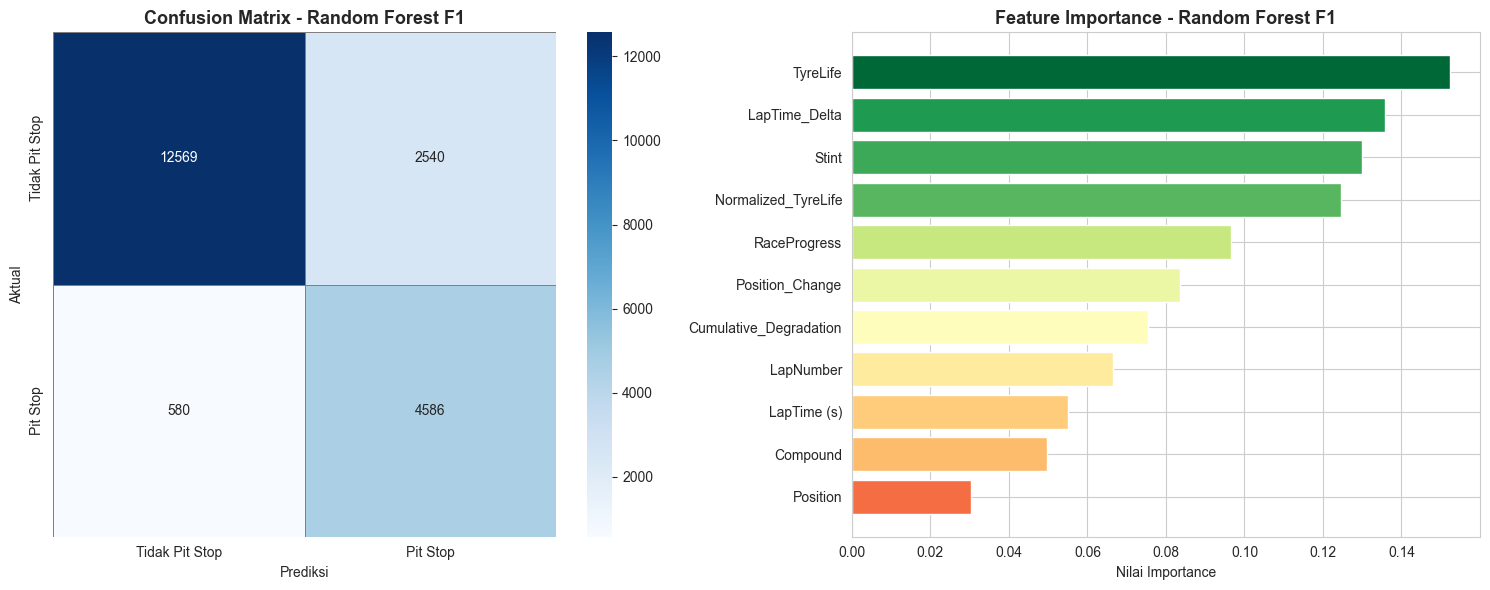

In [15]:
# Visualisasi Confusion Matrix dan Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ============================================================
# Plot 1: Confusion Matrix
# ============================================================

# Membuat confusion matrix dari data aktual dan hasil prediksi
cm = confusion_matrix(y_test, y_pred)

# Menampilkan confusion matrix dalam bentuk heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0],
    linewidths=0.5,
    linecolor='gray'
)

# Memberikan judul pada plot confusion matrix
axes[0].set_title(
    'Confusion Matrix - Random Forest F1',
    fontweight='bold',
    fontsize=13
)

# Memberikan label pada sumbu x
axes[0].set_xlabel('Prediksi')

# Memberikan label pada sumbu y
axes[0].set_ylabel('Aktual')

# ============================================================
# Plot 2: Feature Importance
# ============================================================

# Membuat dataframe berisi nama fitur dan nilai importance dari model Random Forest
importance_df = pd.DataFrame({
    'Fitur': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Membuat warna batang berdasarkan besar kecilnya nilai importance
colors = plt.cm.RdYlGn(
    importance_df['Importance'] /
    importance_df['Importance'].max()
)

# Membuat grafik horizontal bar untuk menampilkan feature importance
axes[1].barh(
    importance_df['Fitur'],
    importance_df['Importance'],
    color=colors,
    edgecolor='white'
)

# Memberikan judul pada plot feature importance
axes[1].set_title(
    'Feature Importance - Random Forest F1',
    fontweight='bold',
    fontsize=13
)

# Memberikan label sumbu x
axes[1].set_xlabel('Nilai Importance')

# Merapikan layout agar grafik tidak bertumpuk
plt.tight_layout()

# Menampilkan visualisasi
plt.show()

----------------------------------------------------------------------
RINGKASAN MODEL KLASIFIKASI PREDIKSI PIT STOP F1
----------------------------------------------------------------------
                Studi Kasus     Algoritma Accuracy Precision Recall F1-Score
Prediksi Pit Stop Formula 1 Random Forest    84.6%    0.8763 0.8461   0.8530


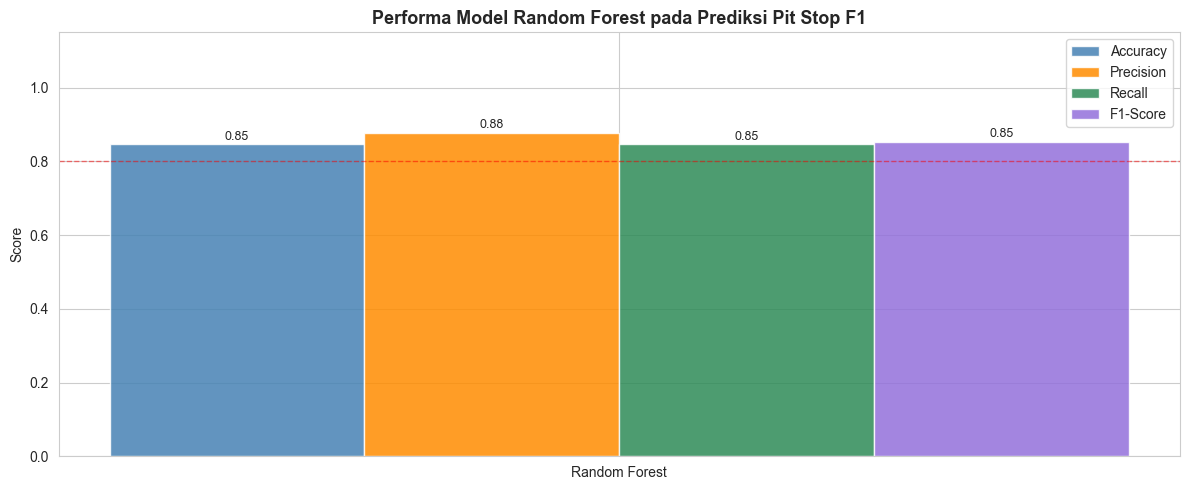

In [16]:
# ============================================================
# RINGKASAN AKHIR
# ============================================================

print('-' * 70)
print('RINGKASAN MODEL KLASIFIKASI PREDIKSI PIT STOP F1')
print('-' * 70)

summary = pd.DataFrame({
    'Studi Kasus': [
        'Prediksi Pit Stop Formula 1'
    ],

    'Algoritma': [
        'Random Forest'
    ],

    'Accuracy': [f'{acc*100:.1f}%'],
    'Precision': [f'{prec:.4f}'],
    'Recall': [f'{rec:.4f}'],
    'F1-Score': [f'{f1:.4f}']
})

print(summary.to_string(index=False))


# ============================================================
# Visualisasi Performa Model
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

models = ['Random Forest']

metrics = {
    'Accuracy' : [acc],
    'Precision': [prec],
    'Recall'   : [rec],
    'F1-Score' : [f1]
}

x = np.arange(len(models))
width = 0.2

colors_bar = [
    'steelblue',
    'darkorange',
    'seagreen',
    'mediumpurple'
]

for i, (metric, values) in enumerate(metrics.items()):

    bars = ax.bar(
        x + i*width,
        values,
        width,
        label=metric,
        color=colors_bar[i],
        alpha=0.85,
        edgecolor='white'
    )

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.15)

ax.set_title(
    'Performa Model Random Forest pada Prediksi Pit Stop F1',
    fontweight='bold',
    fontsize=13
)

ax.set_ylabel('Score')
ax.legend()

ax.axhline(
    y=0.8,
    color='red',
    linestyle='--',
    linewidth=1,
    alpha=0.5
)

plt.tight_layout()
plt.show()

# KESIMPULAN CRISP-DM:

1. Business Understanding

   Studi kasus ini bertujuan untuk memprediksi apakah pembalap Formula 1
   akan melakukan pit stop berdasarkan kondisi balapan dan karakteristik ban.

3. Data Understanding

   Dataset dianalisis melalui pengecekan struktur data, tipe data,
   missing value, duplikat, distribusi target, serta pola fitur seperti
   TyreLife, LapNumber, Position, Compound, dan LapTime.

5. Data Preparation

   Proses persiapan data meliputi penghapusan duplikat, pembersihan whitespace,
   standardisasi nilai kategorikal, pengecekan nilai tidak valid,
   imputasi missing value, serta encoding data kategorikal.

7. Modeling

   Model yang digunakan adalah Random Forest untuk melakukan klasifikasi
   prediksi pit stop Formula 1. Algoritma ini dipilih karena mampu
   menangani dataset berukuran besar, menghasilkan performa klasifikasi
   yang baik, serta dapat mengidentifikasi fitur-fitur yang paling
   berpengaruh terhadap keputusan pit stop.

8. Evaluation

   Evaluasi dilakukan menggunakan Accuracy, Precision, Recall, F1-Score,
   Confusion Matrix, Feature Importance, dan Cross Validation.

10. Deployment

    Model dapat digunakan sebagai sistem pendukung keputusan untuk membantu tim strategi dalam memperkirakan kemungkinan pit stop pada kondisi tertentu.

## Kesimpulan akhir:
Model Random Forest berhasil digunakan untuk melakukan klasifikasi
prediksi pit stop Formula 1 berdasarkan kondisi balapan dan kondisi ban.

Berdasarkan hasil evaluasi menggunakan Accuracy, Precision, Recall,
F1-Score, Confusion Matrix, dan Cross Validation, model mampu
mempelajari pola keputusan pit stop dengan baik.

Hasil Feature Importance menunjukkan bahwa beberapa variabel seperti
TyreLife, LapTime_Delta, Position, RaceProgress, dan Cumulative_Degradation
memiliki pengaruh besar terhadap keputusan pit stop.

Model yang dihasilkan dapat digunakan sebagai pendukung analisis strategi
balapan Formula 1 dan menjadi contoh penerapan metode Data Mining
menggunakan framework CRISP-DM pada studi kasus klasifikasi.